In [1]:
# =========================
# DCGAN (CIFAR-10) 전체 코드
# - 기본 GAN(MNIST/MLP) -> DCGAN(CIFAR10/Conv) 변환 버전
# - 동일한 형식(Generator/Discriminator, train_* 함수, 학습 루프, loss 기록/저장)
# =========================

from tqdm import tqdm  # 진행률 바 표시

import os  # 폴더 생성 등
import torch  # PyTorch
import torch.nn as nn  # 신경망 모듈
import torch.optim as optim  # 옵티마이저
from torch.utils.data import DataLoader  # 데이터로더
import matplotlib.pylab as plt  # 그래프 출력

from torchvision.utils import make_grid, save_image  # 그리드 생성/이미지 저장
import torchvision.datasets as datasets  # CIFAR10 데이터셋
import torchvision.transforms as transforms  # 전처리

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # GPU 있으면 CUDA, 없으면 CPU


In [2]:
# -------------------------
# 1) 하이퍼파라미터 설정
# -------------------------
batch_size = 64  # 배치 크기
epochs = 25     # epoch 수
nz = 128          # 잠재벡터 z 차원
lr = 2e-4         # 학습률
beta1 = 0.5       # DCGAN 권장 Adam beta1
k = 1             # 한 배치에서 Discriminator 업데이트 횟수(보통 1)

# 샘플 저장 관련
sample_dir = "./data_gen/dcgan_cifar10/img"  # 생성 이미지 저장 폴더
os.makedirs(sample_dir, exist_ok=True)  # 폴더 없으면 생성


In [3]:
# -------------------------
# 2) 데이터셋(CIFAR-10) 로드
# -------------------------
# CIFAR-10: (3, 32, 32)
# Tanh 출력에 맞추기 위해 [-1, 1] 범위로 정규화
transform = transforms.Compose([
    transforms.ToTensor(),  # [0,255] -> [0,1]
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),  # [0,1] -> [-1,1]
])

train_dataset = datasets.CIFAR10(
    root="./data_dcgan_cifar10",
    train=True,
    transform=transform,
    download=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,      # # 환경에 맞게 조절(Windows/Colab은 0~2 권장)
    pin_memory=False     # # GPU 사용 시 전송 속도 약간 개선
)


C:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [4]:
# 3) DCGAN 모델 정의
def weights_init(m):
    """# DCGAN 권장 가중치 초기화(Conv/BN)"""
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)  # # 평균0, 표준편차0.02
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)  # # BN weight는 평균1
        nn.init.constant_(m.bias.data, 0)
class Generator(nn.Module):
    """# DCGAN 생성자: z(배치,nz,1,1) -> 이미지(배치,3,32,32)"""
    def __init__(self, nz, ngf=64):
        super(Generator, self).__init__()
        self.nz = nz  # # 잠재벡터 차원
        self.main = nn.Sequential(
            # (nz,1,1) -> (ngf*4,4,4)
            nn.ConvTranspose2d(nz, ngf * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),

            # (ngf*4,4,4) -> (ngf*2,8,8)
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),

            # (ngf*2,8,8) -> (ngf,16,16)
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            # (ngf,16,16) -> (3,32,32)
            nn.ConvTranspose2d(ngf, 3, 4, 2, 1, bias=False),
            nn.Tanh(),  # # 출력 범위 [-1,1]
        )
    def forward(self, x):
        return self.main(x)


In [5]:
class Discriminator(nn.Module):
    """# DCGAN 판별자: 이미지(배치,3,32,32) -> 확률(배치,1)"""
    def __init__(self, ndf=64):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # (3,32,32) -> (ndf,16,16)  (첫 레이어는 BN 보통 생략)
            nn.Conv2d(3, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # (ndf,16,16) -> (ndf*2,8,8)
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            # (ndf*2,8,8) -> (ndf*4,4,4)
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),

            # (ndf*4,4,4) -> (1,1,1)
            nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid(),  # # 확률 출력(0~1)
        )

    def forward(self, x):
        out = self.main(x)              # # (B,1,1,1)
        return out.view(-1, 1)          # # (B,1)로 reshape


In [6]:
# -------------------------
# 4) 모델 생성/초기화
# -------------------------
generator = Generator(nz).to(device)         # 생성자
discriminator = Discriminator().to(device)   # 판별자

generator.apply(weights_init)        # # DCGAN 초기화 적용
discriminator.apply(weights_init)

print(generator)
print(discriminator)


Generator(
  (main): Sequential(
    (0): ConvTranspose2d(128, 256, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): Tanh()
  )
)
Discriminator(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4)

In [7]:
# -------------------------
# 5) 옵티마이저/손실함수
# -------------------------
optim_g = optim.Adam(generator.parameters(), lr=lr, betas=(beta1, 0.999))       # # DCGAN 권장 betas
optim_d = optim.Adam(discriminator.parameters(), lr=lr/2, betas=(beta1, 0.999))

criterion = nn.BCELoss()  # # 이진분류 손실(진짜=1, 가짜=0)

losses_g = []  # # 생성자 loss 기록
losses_d = []  # # 판별자 loss 기록
images = []    # # epoch별 샘플 그리드 기록(선택)

# -------------------------
# 6) 이미지 저장 함수
# -------------------------
def save_generator_image(grid, path):
    """# make_grid 결과를 파일로 저장"""
    save_image(grid, path)

# 고정 노이즈(매 epoch 같은 z로 샘플 생성하면 변화 비교가 쉬움)
fixed_z = torch.randn(25, nz, 1, 1, device=device)  # # 25개(5x5)


In [8]:
# 7) 학습 함수(형식 유지)
def train_discriminator(optimizer, data_real, data_fake):
    """# 판별자 학습: 진짜는 1, 가짜는 0으로 맞히기"""
    b_size = data_real.size(0)
  #  real_label = torch.ones(b_size, 1, device=device)   # # 진짜 라벨
 # 1.0 대신 0.9를 사용하여 D가 너무 강하게 확신하는 것을 방지 (One-sided Label Smoothing)  
    real_label = torch.full((b_size, 1), 0.9, device=device)
    fake_label = torch.zeros(b_size, 1, device=device)  # # 가짜 라벨

    optimizer.zero_grad(set_to_none=True)  # # gradient 초기화

    # # 진짜 손실
    output_real = discriminator(data_real)
    loss_real = criterion(output_real, real_label)

    # # 가짜 손실
    output_fake = discriminator(data_fake)
    loss_fake = criterion(output_fake, fake_label)

    loss = loss_real + loss_fake  # # 합쳐서 1번만 backward
    loss.backward()
    optimizer.step()
    return loss

def train_generator(optimizer, data_fake):
    """# 생성자 학습: 가짜를 진짜(1)로 속이기"""
    b_size = data_fake.size(0)
    real_label = torch.ones(b_size, 1, device=device)  # # G 목표 라벨(진짜)
    optimizer.zero_grad(set_to_none=True)
    output = discriminator(data_fake)      # # D(G(z))
    loss = criterion(output, real_label)   # # 가짜를 1로 분류하게

    loss.backward()
    optimizer.step()

    return loss


In [9]:
# 8) 학습 루프
num_batches = len(train_loader)

generator.train()
discriminator.train()
for epoch in range(epochs):
    loss_g = 0.0  # # epoch 누적 G loss(float)
    loss_d = 0.0  # # epoch 누적 D loss(float)

    for idx, (real_images, _) in tqdm(enumerate(train_loader), total=num_batches):
        real_images = real_images.to(device)
        b_size = real_images.size(0)
        # (1) 판별자 업데이트 k번
        for _ in range(k):
            # # D 학습용 fake는 G 그래프 추적 불필요 -> no_grad로 속도/메모리 절약
            with torch.no_grad():
                z = torch.randn(b_size, nz, 1, 1, device=device)  # # (B,nz,1,1)
                fake_images = generator(z)
            d_loss = train_discriminator(optim_d, real_images, fake_images)
            loss_d += d_loss.item()

        # (2) 생성자 업데이트 1번(여기는 grad 필요)
        z = torch.randn(b_size, nz, 1, 1, device=device)
        fake_images = generator(z)
        g_loss = train_generator(optim_g, fake_images)
        loss_g += g_loss.item()

    # (3) epoch 평균 손실 기록
    epoch_loss_g = loss_g / num_batches
    epoch_loss_d = loss_d / num_batches
    losses_g.append(epoch_loss_g)
    losses_d.append(epoch_loss_d)

    # (4) epoch마다 5x5 샘플 저장(고정 z 사용)
    with torch.no_grad():
        gen = generator(fixed_z).cpu()  # # (25,3,32,32)
    grid = make_grid(gen, nrow=5, normalize=True, value_range=(-1, 1))  # # 5x5 그리드
    save_generator_image(grid, f"{sample_dir}/gen_5x5_epoch_{epoch:03d}.png")
    images.append(grid)

    print(f"Epoch {epoch} of {epochs}")
    print(f"Generator loss: {epoch_loss_g:.6f}, Discriminator loss: {epoch_loss_d:.6f}")

    with torch.no_grad():
        Dx  = discriminator(real_images).mean().item()
        DGz = discriminator(fake_images).mean().item()
    print(f"[epoch {epoch}] Dx={Dx:.3f}, DGz={DGz:.3f}")


100%|████████████████████████████████████████████████████████████████████████████████| 782/782 [00:08<00:00, 87.87it/s]


Epoch 0 of 25
Generator loss: 2.411644, Discriminator loss: 0.934997
[epoch 0] Dx=0.797, DGz=0.149


100%|████████████████████████████████████████████████████████████████████████████████| 782/782 [00:08<00:00, 90.49it/s]


Epoch 1 of 25
Generator loss: 2.209488, Discriminator loss: 0.847438
[epoch 1] Dx=0.835, DGz=0.090


100%|████████████████████████████████████████████████████████████████████████████████| 782/782 [00:08<00:00, 91.50it/s]


...

Epoch 22 of 25
Generator loss: 1.674267, Discriminator loss: 0.910204
[epoch 22] Dx=0.704, DGz=0.142


100%|████████████████████████████████████████████████████████████████████████████████| 782/782 [00:08<00:00, 92.05it/s]


Epoch 23 of 25
Generator loss: 1.695363, Discriminator loss: 0.909421
[epoch 23] Dx=0.880, DGz=0.358


100%|████████████████████████████████████████████████████████████████████████████████| 782/782 [00:08<00:00, 90.59it/s]

Epoch 24 of 25
Generator loss: 1.715975, Discriminator loss: 0.872866
[epoch 24] Dx=0.954, DGz=0.504


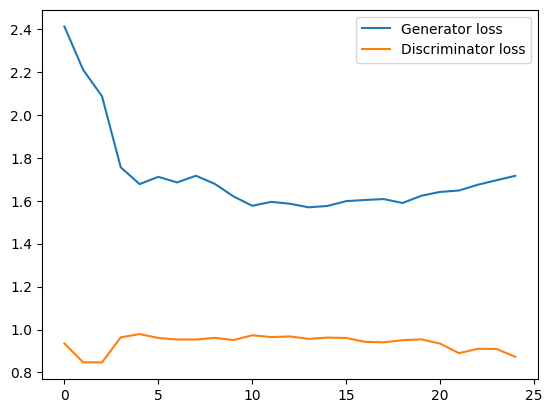

In [10]:
# -------------------------
# 9) 손실 그래프 출력
# -------------------------
plt.figure()
plt.plot(losses_g, label="Generator loss")      # # 생성자 손실
plt.plot(losses_d, label="Discriminator loss")  # # 판별자 손실
plt.legend()
plt.show()


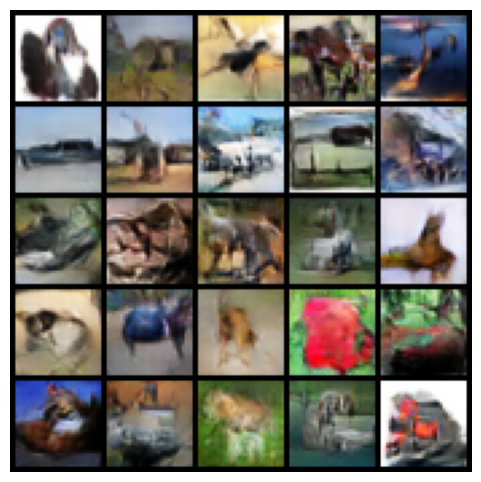

In [11]:
# -------------------------
# 10) 마지막 epoch 샘플 25장(5x5) 화면에 출력(선택)
# -------------------------
plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0))  # # (C,H,W)->(H,W,C)로 변환 후 표시
plt.axis("off")
plt.show()
